In [2]:
!pip install -q transformers accelerate faiss-cpu ultralytics pillow

In [37]:
import pandas as pd
import json
import os
from tqdm import tqdm
from PIL import Image
import os
from pathlib import Path
from ultralytics import YOLO
import cv2
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import Blip2Processor, Blip2ForConditionalGeneration, Blip2ForImageTextRetrieval
from transformers import CLIPProcessor, CLIPModel
from transformers import CLIPVisionModelWithProjection, CLIPTextModelWithProjection
import torch
import torch.nn.functional as F
from PIL import Image
import faiss
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
from tqdm.auto import tqdm
from functools import partial
from torch.utils.data import Sampler
import random
from collections import defaultdict
import math

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()

In [5]:
IMG_ROOT   = Path("/kaggle/input/datasets/shanmukhpraneeth/image-data/img")          
BBOX_FILE  = Path("/kaggle/input/datasets/shanmukhpraneeth/boundingbox-data/list_bbox_inshop.txt")
SPLIT_FILE = Path("/kaggle/input/datasets/shanmukhpraneeth/split-data/list_eval_partition.txt")

In [6]:
def load_bbox(anno_path: Path = BBOX_FILE) -> pd.DataFrame:
    """
    Parse list_bbox_inshop.txt.
    Format (after 2-line header):
        image_name  clothes_type  variation_type  x1  y1  x2  y2
    """
    with open(anno_path) as f:
        lines = f.read().splitlines()

    n_items = int(lines[0].strip())
    # line 1 is the column header – skip it
    records = []
    for line in lines[2: 2 + n_items]:
        parts = line.split()
        records.append({
            "image_name":     parts[0],
            "clothes_type":   int(parts[1]),
            "pose_type": int(parts[2]),
            "x1": int(parts[3]),
            "y1": int(parts[4]),
            "x2": int(parts[5]),
            "y2": int(parts[6]),
        })
    return pd.DataFrame(records)

In [7]:
def load_eval_partition(eval_path: Path = SPLIT_FILE) -> pd.DataFrame:
    """
    Parse list_eval_partition.txt.
    Format (after 2-line header):
        image_name  evaluation_status  item_id
    evaluation_status: train | query | gallery
    """
    with open(eval_path) as f:
        lines = f.read().splitlines()

    n_items = int(lines[0].strip())
    records = []
    for line in lines[2: 2 + n_items]:
        parts = line.split()
        records.append({
            "image_name": parts[0],
            "item_id":    parts[1],
            "split":      parts[2],
        })
    return pd.DataFrame(records)

In [8]:
def build_master_df() -> pd.DataFrame:
    """
    Merge bbox and partition annotations into one master DataFrame.

    image_name in the annotation files looks like:
        img/MEN/Denim/id_00000080/01_1_front.jpg
    We resolve the full path as:
        /kaggle/input/image-data/img/MEN/...

    Returns columns:
        image_name, item_id, split, x1, y1, x2, y2,
        clothes_type, variation_type, image_path
    """
    bbox_df = load_bbox()
    eval_df = load_eval_partition()

    df = eval_df.merge(bbox_df, on="image_name", how="left")

    # image_name already starts with "img/", so just prepend the dataset root
    df["image_path"] = df["image_name"].apply(
        lambda p: str(IMG_ROOT / p.split("img/", 1)[-1])
    )
    return df

In [10]:
class DeepFashionDataset(Dataset):
    """
    Returns (image_tensor, item_id_string, image_name) for a given split.

    df        : master DataFrame from build_master_df()
    split     : 'train' | 'query' | 'gallery'
    transform : torchvision / CLIP pre-process callable
    use_bbox  : crop to annotated bounding box before transform
    """

    def __init__(self, df: pd.DataFrame, split: str,
                 transform=None, use_bbox: bool = True):
        self.df        = df[df["split"] == split].reset_index(drop=True)
        self.transform = transform
        self.use_bbox  = use_bbox

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")

        if self.use_bbox and not pd.isna(row.get("x1", float("nan"))):
            x1, y1, x2, y2 = int(row.x1), int(row.y1), int(row.x2), int(row.y2)
            w, h = img.size
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            if x2 > x1 and y2 > y1:
                img = img.crop((x1, y1, x2, y2))

        if self.transform:
            img = self.transform(img)

        return img, row["item_id"], row["image_name"]

<class 'PIL.Image.Image'>
id_00000002
img/WOMEN/Dresses/id_00000002/02_1_front.jpg


(np.float64(-0.5), np.float64(167.5), np.float64(206.5), np.float64(-0.5))

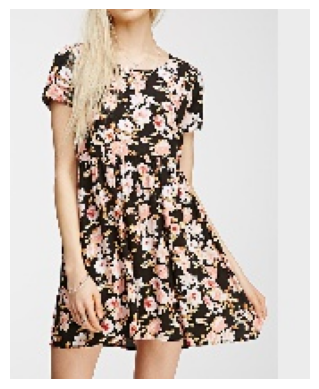

In [11]:
# Step 1: build dataframe
df = build_master_df()

# Step 2: create dataset
train_ds = DeepFashionDataset(df, "train")

# Step 3: test
img, item_id, name = train_ds[0]

print(type(img))
print(item_id)
print(name)

plt.imshow(img)
plt.axis("off")

Image Cropping Using YOLO

In [31]:
# Load model ONCE
yolo_pose = YOLO("yolov8s.pt")

gallery_ds = DeepFashionDataset(df, "gallery")

SAVE_DIR = "/kaggle/working/yolo_crops"
os.makedirs(SAVE_DIR, exist_ok=True)

In [32]:
def yolo_pose_crop(img):

    results = yolo_pose(
        img,
        verbose=False
    )[0]

    boxes = results.boxes

    person_idx = None
    best_area = 0

    # --------------------------------------------------------
    # Find largest person
    # --------------------------------------------------------

    if boxes is not None and len(boxes) > 0:

        for i, box in enumerate(boxes):

            cls = int(box.cls)

            if cls != 0:
                continue

            x1, y1, x2, y2 = (
                box.xyxy[0]
                .cpu()
                .numpy()
            )

            area = (
                (x2 - x1)
                * (y2 - y1)
            )

            if area > best_area:

                best_area = area
                person_idx = i

    # --------------------------------------------------------
    # Crop with padding
    # --------------------------------------------------------

    if person_idx is not None:

        x1, y1, x2, y2 = (
            boxes.xyxy[person_idx]
            .cpu()
            .numpy()
        )

        x1, y1, x2, y2 = map(
            int,
            [x1, y1, x2, y2]
        )

        w, h = img.size

        # ----------------------------------------------------
        # Adaptive padding
        # ----------------------------------------------------

        bw = x2 - x1
        bh = y2 - y1

        pad_x = int(0.08 * bw)
        pad_y = int(0.05 * bh)

        x1 = max(0, x1 - pad_x)
        y1 = max(0, y1 - pad_y)

        x2 = min(w, x2 + pad_x)
        y2 = min(h, y2 + pad_y)

        # ----------------------------------------------------
        # Final crop
        # ----------------------------------------------------

        if x2 > x1 and y2 > y1:

            return img.crop(
                (x1, y1, x2, y2)
            )

    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    return img

In [33]:
metadata = []

for i in tqdm(range(len(gallery_ds))):
    img, item_id, name = gallery_ds[i]

    try:
        # -------------------------------
        # YOLO CROP
        # -------------------------------
        crop = yolo_pose_crop(img)

        # -------------------------------
        # SAVE CROP
        # -------------------------------
        save_name = name.replace("/", "_")
        save_path = os.path.join(SAVE_DIR, save_name)

        crop.save(save_path)

        # -------------------------------
        # STORE METADATA
        # -------------------------------
        metadata.append({
            "image_name": name,
            "item_id": item_id,
            "crop_path": save_path
        })

    except Exception as e:
        print(f"Error at index {i}: {e}")
        continue

  0%|          | 0/12612 [00:00<?, ?it/s]

In [34]:
jsonl_path = "/kaggle/working/yolo_metadata.jsonl"

with open(jsonl_path, "w") as f:

    for entry in metadata:

        crop_path = entry["crop_path"]

        record = {

            "image_name": entry["image_name"],

            "item_id": entry["item_id"],

            "crop_path": crop_path,

            "crop_name": os.path.basename(
                crop_path
            )
        }

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            ) + "\n"
        )

print("Saved:", jsonl_path)

Saved: /kaggle/working/yolo_metadata.jsonl


Total crops: 12612


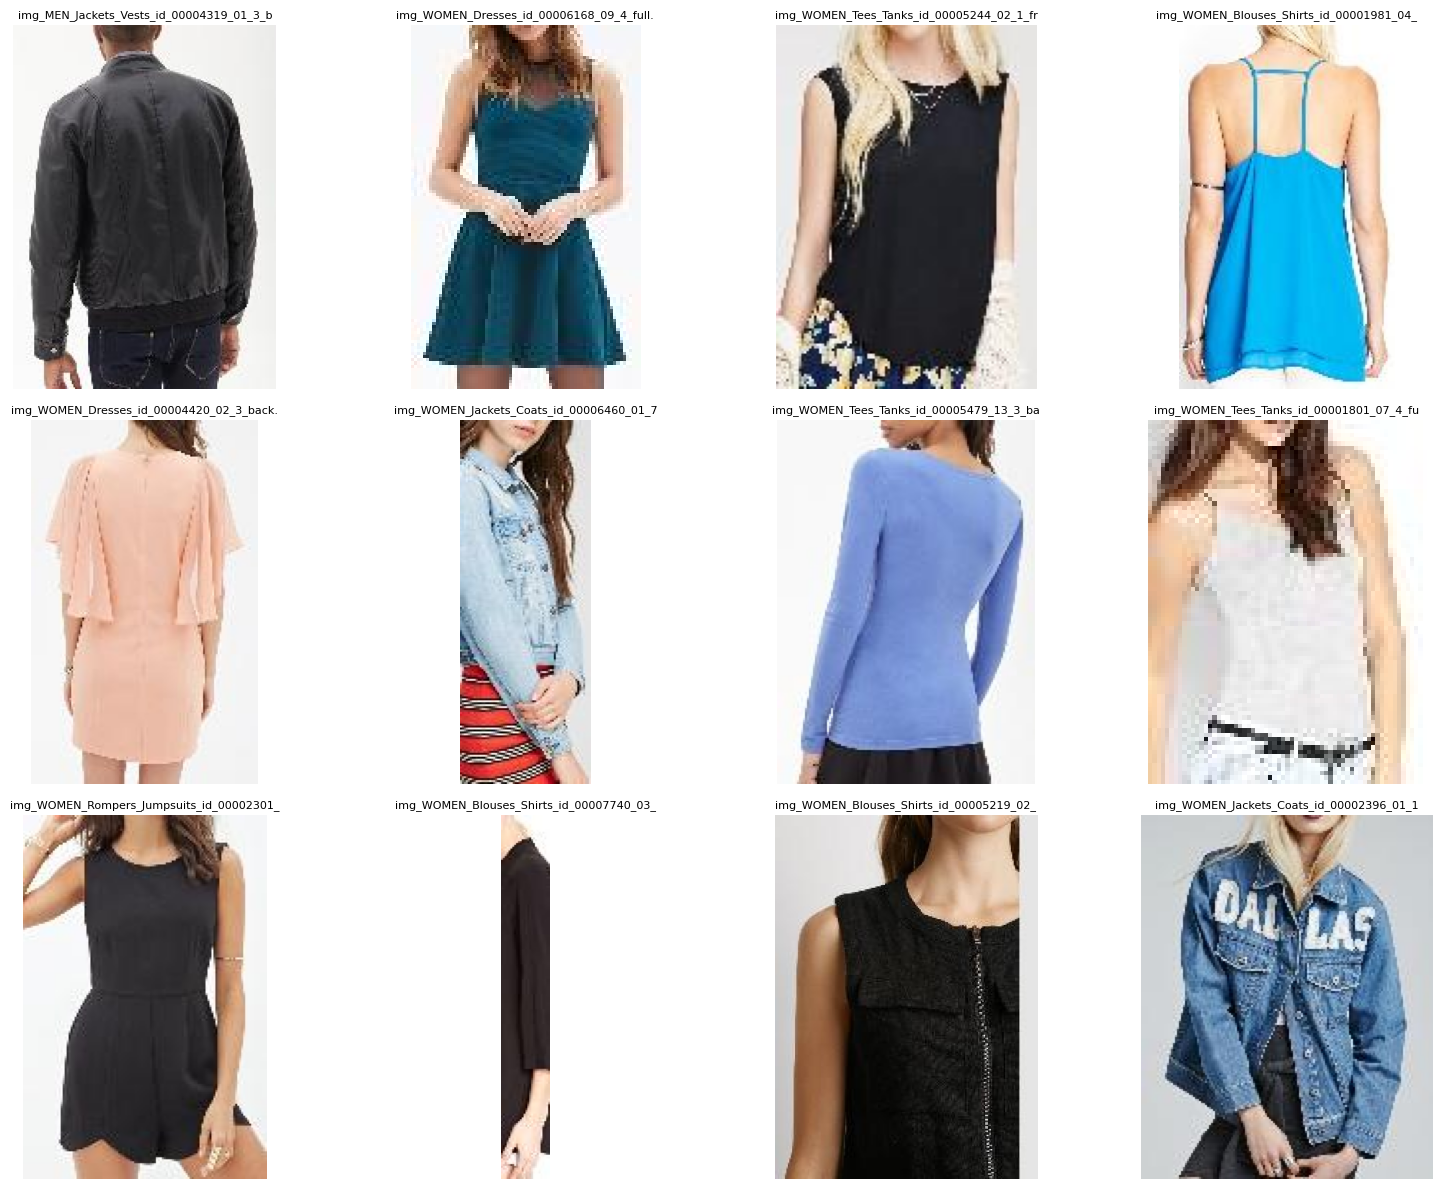

In [43]:
crop_dir = "/kaggle/working/yolo_crops"

# ============================================================
# GET ALL IMAGE FILES
# ============================================================

crop_files = [

    f for f in os.listdir(crop_dir)

    if f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]

print("Total crops:", len(crop_files))

# ============================================================
# RANDOMLY SAMPLE CROPS
# ============================================================

sample_files = random.sample(
    crop_files,
    min(12, len(crop_files))
)

# ============================================================
# DISPLAY CROPS
# ============================================================

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, file_name in zip(axes, sample_files):

    img_path = os.path.join(
        crop_dir,
        file_name
    )

    img = Image.open(img_path)

    ax.imshow(img)

    ax.set_title(
        file_name[:40],
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

Caption Generation Using BLIP

In [45]:
device = ("cuda")

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base",
    use_fast=False
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

model.eval()

print("BLIP-base loaded successfully.")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP-base loaded successfully.


In [67]:
def generate_caption(img):

    prompt = "a detailed fashion product description of"

    # 1) Pass prompt THROUGH processor
    inputs = processor(
        images=img,
        text=prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=45,
            num_beams=3,
            length_penalty=1.0,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )

    # 2) TOKEN-LEVEL TRIM (the key step)
    input_len = inputs["input_ids"].shape[1]
    generated_ids = out[0][input_len:]

    caption = processor.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return caption

In [68]:
yolo_metadata_path = "/kaggle/working/yolo_metadata.jsonl"

metadata = []

with open(yolo_metadata_path, "r") as f:

    for line in f:

        metadata.append(
            json.loads(line)
        )

print("Total crops:", len(metadata))

Total crops: 12612


In [ ]:
captions_path = "/kaggle/working/captions.jsonl"

with open(captions_path, "w") as out_f:

    for i, row in enumerate(tqdm(metadata)):

        try:
            crop_path = row["crop_path"]

            crop = Image.open(
                crop_path
            ).convert("RGB")
            caption = generate_caption(
                crop
            )
            record = {

                "image_name": row["image_name"],

                "item_id": row["item_id"],

                "caption": caption
            }

            out_f.write(
                json.dumps(record)
                + "\n"
            )
            out_f.flush()

        except Exception as e:

            print(
                f"Error at {i}: {e}"
            )

            continue

        if i % 10 == 0:

            torch.cuda.empty_cache()

print("\nCaption generation completed.")
print("Saved to:", captions_path)

  0%|          | 0/12612 [00:00<?, ?it/s]

In [ ]:
caption_map = {}

with open("/kaggle/working/captions.jsonl", "r") as f:
    for line in f:
        row = json.loads(line)

        caption_map[row["image_name"]] = row["caption"]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model.eval()

In [ ]:
def get_image_embedding(image):

    inputs = clip_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        pooled = outputs.pooler_output

        features = clip_model.visual_projection(
            pooled
        )

    features = F.normalize(
        features,
        p=2,
        dim=-1
    )

    return features

In [ ]:
def get_text_embedding(text):

    inputs = clip_processor(
        text=[text],
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = clip_model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        pooled = outputs.pooler_output

        features = clip_model.text_projection(
            pooled
        )

    features = F.normalize(
        features,
        p=2,
        dim=-1
    )

    return features

In [ ]:
def fuse_embeddings(img_emb, txt_emb, alpha):

    fused = (
        alpha * img_emb
        + (1 - alpha) * txt_emb
    )

    fused = F.normalize(
        fused,
        p=2,
        dim=-1
    )

    return fused

In [ ]:
ALPHA = 1

embeddings = []
metadata = []

for i in tqdm(range(len(gallery_ds))):

    try:

        # -----------------------------------
        # ORIGINAL IMAGE INFO
        # -----------------------------------

        img, item_id, image_name = gallery_ds[i]

        # -----------------------------------
        # LOAD SAVED YOLO CROP
        # -----------------------------------

        crop_filename = image_name.replace("/", "_")

        crop_path = (
            f"/kaggle/working/yolo_crops/"
            f"{crop_filename}"
        )

        crop = Image.open(crop_path).convert("RGB")
        caption = caption_map[image_name]
        img_emb = get_image_embedding(crop)
        txt_emb = get_text_embedding(caption)


        fused_emb = fuse_embeddings(
            img_emb,
            txt_emb,
            alpha=ALPHA
        )

        embeddings.append(
            fused_emb.cpu().numpy()[0]
        )

        metadata.append({
            "image_name": image_name,
            "item_id": item_id,
            "caption": caption
        })

    except Exception as e:

        print(f"Error at {i}: {e}")

    if i % 50 == 0:
        torch.cuda.empty_cache()

In [ ]:
embeddings = np.array(
    embeddings,
    dtype=np.float32
)

print(embeddings.shape)

In [ ]:
dim = embeddings.shape[1]

index = faiss.IndexHNSWFlat(
    dim,
    32
)

# cosine similarity
index.metric_type = faiss.METRIC_INNER_PRODUCT

# HNSW params
index.hnsw.efConstruction = 200
index.hnsw.efSearch = 128

# add vectors
index.add(embeddings)

print(index.ntotal)

In [ ]:
faiss.write_index(
    index,
    "/kaggle/working/hnsw_B_07.bin"
)

In [ ]:
with open(
    "/kaggle/working/metadata_B_07.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

Online Query Retrieval

In [ ]:
index = faiss.read_index(
    "/kaggle/working/hnsw_B_07.bin"
)

# ============================================================
# LOAD METADATA
# ============================================================

with open(
    "/kaggle/working/metadata_B_07.json",
    "r"
) as f:

    metadata = json.load(f)

print("Index loaded:", index.ntotal)

In [ ]:
ALPHA = 0.7

def get_query_embedding(query_crop):
    img_emb = get_image_embedding(
        query_crop
    )

    query_caption = generate_caption(
        query_crop
    )

    print("Generated Query Caption:")
    print(query_caption)

    txt_emb = get_text_embedding(
        query_caption
    )

    fused_emb = (
        ALPHA * img_emb
        + (1 - ALPHA) * txt_emb
    )

    fused_emb = F.normalize(
        fused_emb,
        p=2,
        dim=-1
    )

    return (
        fused_emb
        .cpu()
        .numpy()
        .astype("float32")
    )

In [ ]:
query_ds = DeepFashionDataset(
    df,
    "query"
)

# choose query index
query_idx = 0

query_img, query_item_id, query_name = query_ds[
    query_idx
]

print("Query item_id:", query_item_id)
print("Query image:", query_name)

plt.figure(figsize=(4,4))
plt.imshow(query_img)
plt.axis("off")
plt.title("Original Query Image")
plt.show()

In [ ]:
query_crop = yolo_pose_crop(
    query_img
)

plt.figure(figsize=(4,4))
plt.imshow(query_crop)
plt.axis("off")
plt.title("YOLO Query Crop")
plt.show()

In [ ]:
query_emb = get_query_embedding(
    query_crop
)

print(query_emb.shape)

In [ ]:
K = 10

scores, indices = index.search(
    query_emb,
    K
)

print("Retrieved indices:")
print(indices)

print("\nSimilarity scores:")
print(scores)

In [ ]:
fig, axs = plt.subplots(
    1,
    K + 1,
    figsize=(20, 5)
)

axs[0].imshow(query_crop)

axs[0].set_title("QUERY")

axs[0].axis("off")


for i, idx in enumerate(indices[0]):

    row = metadata[idx]

    img_path = (
        IMG_ROOT /
        row["image_name"].split("img/", 1)[-1]
    )

    retrieved_img = Image.open(
        img_path
    ).convert("RGB")

    axs[i + 1].imshow(retrieved_img)

    retrieved_item_id = row["item_id"]

    score = scores[0][i]

    correct = (
        retrieved_item_id == query_item_id
    )

    title = (
        f"{'MATCH' if correct else 'WRONG'}\n"
        f"{score:.3f}"
    )

    axs[i + 1].set_title(
        title,
        fontsize=8
    )

    axs[i + 1].axis("off")

plt.tight_layout()

plt.show()